<a href="https://www.kaggle.com/code/eymenakb/electric-vehicle-keras?scriptVersionId=347979611" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Welcome

### This is a basic script for predicting electric vehicle purhcase via keras.

competition: [comptetition](https://www.kaggle.com/competitions/playground-series-s6e9)
kaggle: [kaggle](https://www.kaggle.com/eymenakb)
github: [github](https://github.com/EymenAkb)

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e9/train.csv
/kaggle/input/competitions/playground-series-s6e9/test.csv


## Importing the neccesarry libraries

#### Descriptions and Libraries:

`keras`: A famous DL framework used for creating DL models.

`tensorflow`: The main DL framework on top of the keras.

`matplotlib.pyplot`: Visualization and plotting library.

`seaborn`: Visualization and plotting library.

`math`: native python mathematical work library.

`sci-kit_learn` (sklearn): Optimization, pipelines, composing, preprocessing, folding and every preprocess step handler for ML.

`category_encoders`: Encoding the categorical values (for long and seep values).

In [2]:
import math

import numpy as np
import pandas as pd

import keras
from keras import layers
from keras.models import Model
import tensorflow as tf

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.special import expit

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

#### Plot settings, finding the available styles and using one

In [3]:
#plt.style.available # useful for checking the available plt styles.
plt.style.use("seaborn-v0_8")

## Finding the device

In [4]:
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print(f"GPU Available: {gpus[0].name}")

    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(f"Could not set memory growth for {gpu.name}: {e}")
else:
    print(
        "WARNING: No GPU found! "
        "Check your notebook accelerator settings (e.g., Kaggle/Colab GPU setting)."
    )

GPU Available: /physical_device:GPU:0


## Mini utility methods

### Descriptions:

num_cols: used for selecting numerical_columns, DRY (Don't repeat yourself) code.
cat_cols: used for selecting categorical_columns, DRY (Don't repeat yourself) code.

`feature_all_charge_stations`: feature code, new column that sums up charging stations near home and nearh work.

`feature_km_by_car`: feature code, new column for calculating the km usage per car.

`feature_annual_income_digits`: feature code, new column for each digit of the `Annual_Income_USD`.

`feature_daily_commute_km_digits`: feature code, new column for each digit of the `Daily_Commute_km`.

In [5]:
def num_cols(data: pd.DataFrame) -> list[str]:
    return data.select_dtypes(include=np.number).columns.tolist()


def cat_cols(data: pd.DataFrame) -> list[str]:
    return data.select_dtypes(exclude=np.number).columns.tolist()


def feature_all_charge_stations(
    data: pd.DataFrame,
    copy: bool = False
) -> pd.DataFrame:
    if copy:
        data = data.copy()

    data["all_charge_stations"] = (
        data["Charging_Stations_Near_Home"]
        + data["Charging_Stations_Near_Work"]
    )

    return data


def feature_km_by_car(
    data: pd.DataFrame,
    copy: bool = False
) -> pd.DataFrame:
    if copy:
        data = data.copy()

    cars = data["Number_of_Cars_Owned"].replace(0, np.nan)

    data["km_by_car"] = data["Daily_Commute_km"] / cars

    return data


def feature_annual_income_digits(data: pd.DataFrame, copy: bool = False) -> pd.DataFrame:
    if copy:
        data = data.copy()

    income = data["Annual_Income_USD"].fillna(0).astype(np.int64)

    data["digit_100k"] = ((income // 100_000) % 10).astype(str)
    data["digit_10k"] = ((income // 10_000) % 10).astype(str)
    data["digit_1k"] = ((income // 1_000) % 10).astype(str)
    data["digit_100s"] = ((income // 100) % 10).astype(str)

    for col in ["digit_100k", "digit_10k", "digit_1k", "digit_100s"]:
        data[col] = data[col].astype("category")

    return data


def feature_daily_commute_km_digits(data: pd.DataFrame, copy: bool = False) -> pd.DataFrame:
    if copy:
        data = data.copy()

    daily_com = data["Daily_Commute_km"].fillna(0).astype(np.int64)

    data["commute_digit_100"] = ((daily_com // 100) % 10).astype(str)
    data["commute_digit_10"] = ((daily_com // 10) % 10).astype(str)
    data["commute_digit_1"] = ((daily_com // 1) % 10).astype(str)

    for col in [
        "commute_digit_100",
        "commute_digit_10",
        "commute_digit_1"
    ]:
        data[col] = data[col].astype("category")

    return data

# Loading the data

Handling feature engineering and other variables, removing the target from columns and calculating unique count of cateogrical columns (used for finding which encoding method is useful)

In [6]:
train_df = pd.read_csv(
    "/kaggle/input/competitions/playground-series-s6e9/train.csv",
    index_col=0
)

test_df = pd.read_csv(
    "/kaggle/input/competitions/playground-series-s6e9/test.csv",
    index_col=0
)

target = "Will_Buy_EV"

for df in (train_df, test_df):
    feature_all_charge_stations(df)
    feature_km_by_car(df)
    feature_annual_income_digits(df)
    feature_daily_commute_km_digits(df)

numerical_columns = num_cols(train_df)
categorical_columns = cat_cols(train_df)

if target in numerical_columns:
    numerical_columns.remove(target)

if target in categorical_columns:
    categorical_columns.remove(target)

for col in categorical_columns:
    train_df[col] = train_df[col].astype("string").fillna("Missing")
    test_df[col] = test_df[col].astype("string").fillna("Missing")

for col in categorical_columns:
    train_df[col] = train_df[col].astype(str)
    test_df[col] = test_df[col].astype(str)

print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)

print(
    "\nTotal categorical unique values:",
    train_df[categorical_columns].nunique().sum()
)

train_df.info()

Numerical columns: ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'all_charge_stations', 'km_by_car']
Categorical columns: ['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level', 'digit_100k', 'digit_10k', 'digit_1k', 'digit_100s', 'commute_digit_100', 'commute_digit_10', 'commute_digit_1']

Total categorical unique values: 70
<class 'pandas.core.frame.DataFrame'>
Index: 668665 entries, 0 to 668664
Data columns (total 23 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Age                          668665 non-null  int64  
 1   Annual_Income_USD            668665 non-null  float64
 2   Daily_Commute_km             668665 non-null  float64
 3   Number_of_Cars_Owned         668665 non-null  int64  
 4   Charging_Stations_Near_Home  

#### Based off of the skedewness we are going to use `Embedding`

## Plotting the data

Plotting the categorical_columns using barplot.
Plotting the numerical_columns using histplot, checking the correlation between numerical values using heatmap.

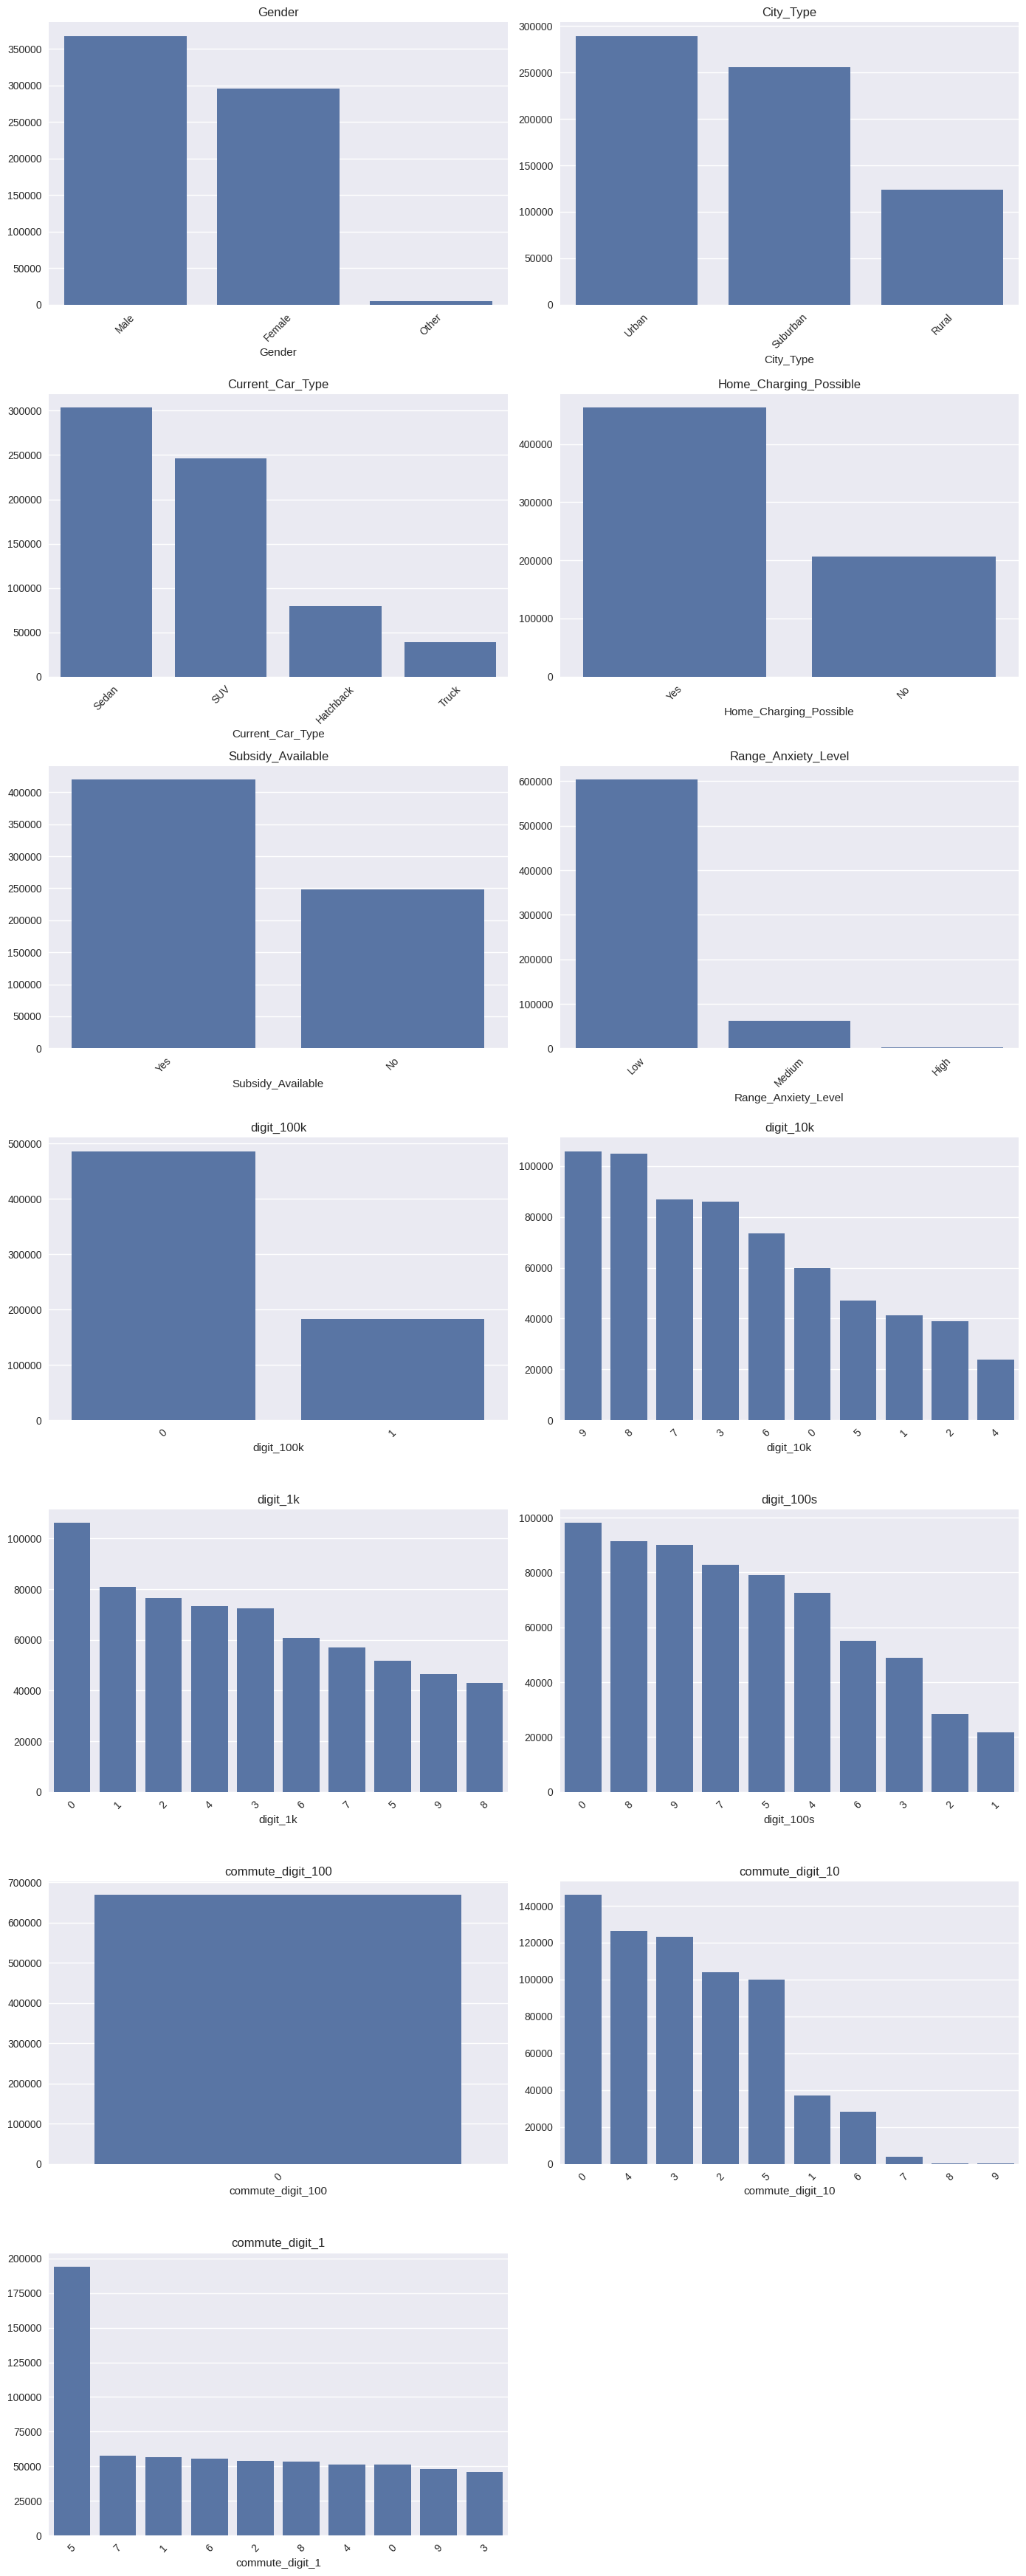

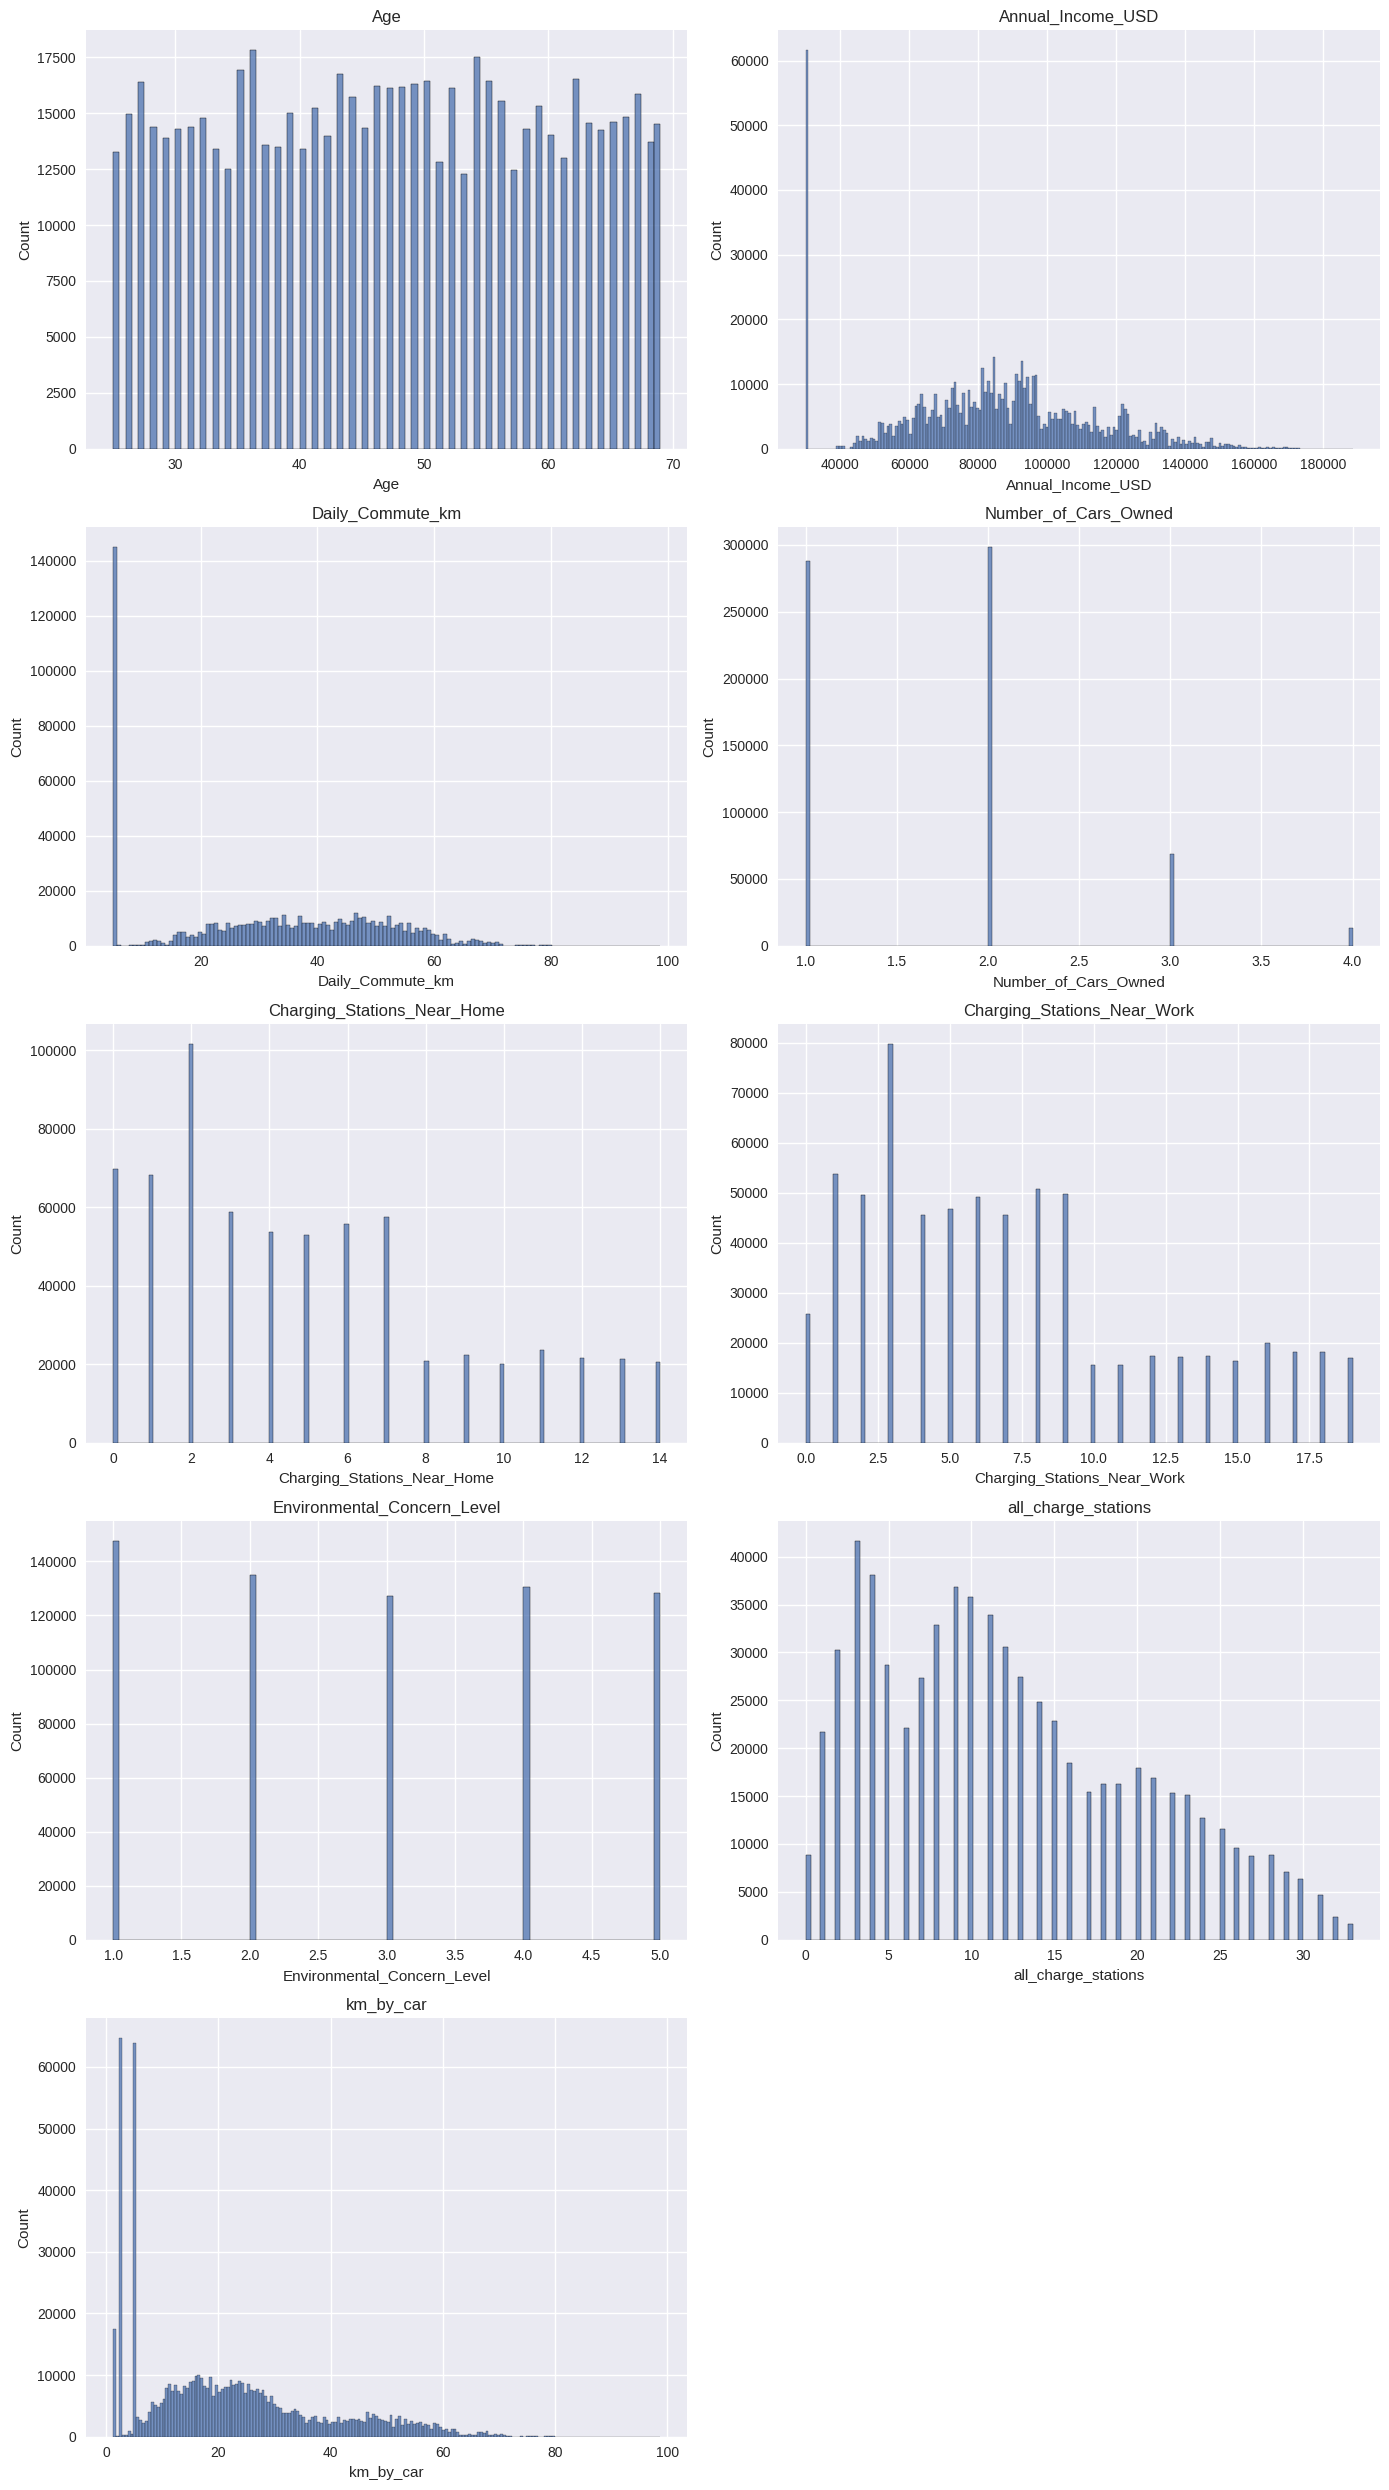

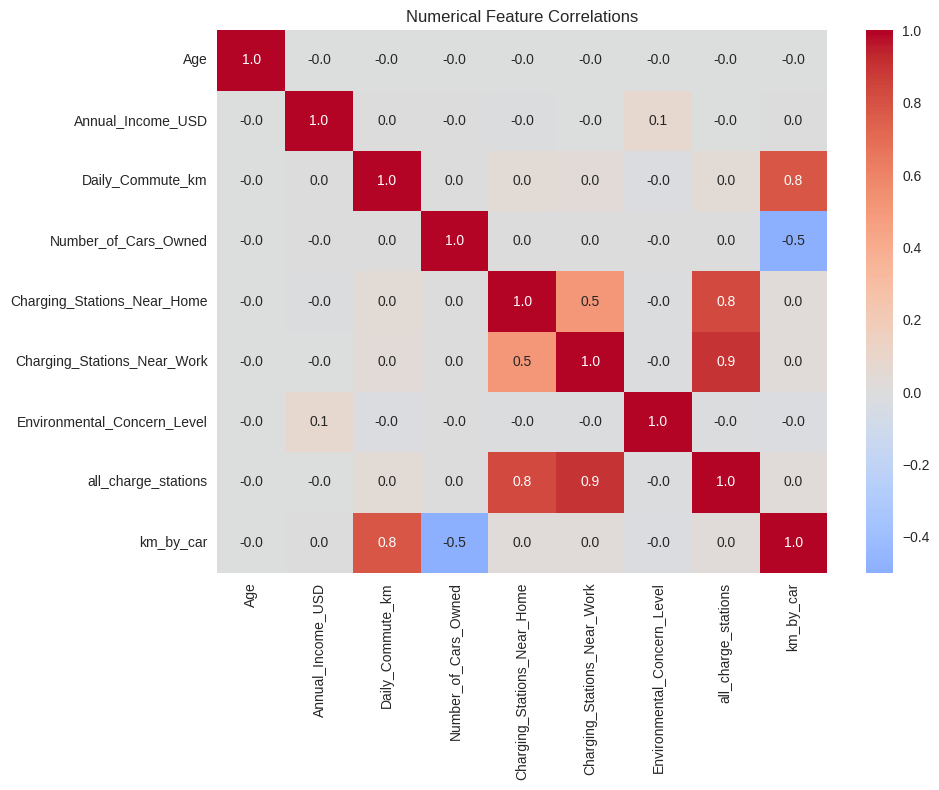

In [7]:
if categorical_columns:
    n_cat = len(categorical_columns)
    ncols = 2
    nrows = math.ceil(n_cat / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 5 * nrows), squeeze=False)

    axes = axes.ravel()

    for i, column in enumerate(categorical_columns):
        counts = train_df[column].value_counts().head(20)

        sns.barplot(x=counts.index, y=counts.values, ax=axes[i])

        axes[i].set_title(column)
        axes[i].tick_params(axis="x", rotation=45)

    for i in range(n_cat, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()


if numerical_columns:
    n_num = len(numerical_columns)
    ncols = 2
    nrows = math.ceil(n_num / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 5 * nrows),squeeze=False)

    axes = axes.ravel()

    for i, column in enumerate(numerical_columns):
        sns.histplot(train_df[column],ax=axes[i])

        axes[i].set_title(column)
    for i in range(n_num, len(axes)):
        axes[i].set_visible(False)
    plt.tight_layout()
    plt.show()

if len(numerical_columns) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(train_df[numerical_columns].corr(), annot=True, fmt=".1f", cmap="coolwarm", center=0)
    plt.title("Numerical Feature Correlations")
    plt.tight_layout()
    plt.show()

# Model

## Defining an automated model creator

`model_create`: given the input layer as `keras.layers.Input` it automatically creates a model with `Dense`, `BatchNormalization`, `LeakyReLU` and `Dropout` layers. 

### Parameters:

`inputs`: takes `list` as its input, for the model

`x_tensor`: The tensor that is going to be passed to the dense layers.

`*hidden`: `int` where you don't spesifiy kew values and any input given here turns into another full layer.

`output_layer`: Currently only works with binary classification, takes `int` as input

`return_model`: `bool` wheter to return as model or as a tuple

`activation`: `keras.layers` to use any provided activation

`use_dropout`: `bool` wheter to use dropout layer or not.

In [8]:
def model_create(inputs, x_tensor, *hidden,output_layer=1,
                 return_model=True, activation=None, use_dropout=True, use_batch_norm=True):
    x = x_tensor

    for units in hidden:
        x = layers.Dense(units)(x)

        if use_batch_norm:
            x = layers.BatchNormalization()(x)

        if activation is not None:
            x = layers.Activation(activation)(x)
        else:
            x = layers.LeakyReLU()(x)

        if use_dropout:
            x = layers.Dropout(0.5)(x)

    x = layers.Dense(output_layer)(x)

    if return_model:
        return Model(inputs=inputs, outputs=x)

    return inputs, x

## Defining another model creator with embedding

`num_features`: `int` is length of the numerical column list.

`cat_cardinalities`: `list` is the categorical columns list passed directly into it.

`unit_shape`: `list` containing `int` for defining the tensors in hidden layers.

In [9]:
def build_embedding_model(num_features: int,cat_cardinalities: list[int],unit_shape: tuple[int, ...] = (128, 64)) -> Model:
    num_input = layers.Input(shape=(num_features,), dtype=tf.float32, name="numerical_input")

    cat_inputs = []
    embeddings = []

    for i, cardinality in enumerate(cat_cardinalities):
        cat_input = layers.Input(shape=(1,), dtype=tf.int32, name=f"cat_input_{i}")

        embedding_dim = min(50,max(2, int(np.ceil(cardinality / 2))))

        embedding = layers.Embedding(input_dim=cardinality + 1, output_dim=embedding_dim, name=f"embedding_{i}")(cat_input)

        embedding = layers.Flatten()(embedding)

        cat_inputs.append(cat_input)
        embeddings.append(embedding)

    x = layers.concatenate([num_input] + embeddings,name="feature_concatenation")

    for units in unit_shape:
        x = layers.Dense(units)(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU()(x)
        x = layers.Dropout(0.3)(x)

    output = layers.Dense(1,activation=None,name="output")(x)

    model = Model(inputs=[num_input] + cat_inputs,outputs=output)

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.BinaryCrossentropy(from_logits=True),
        metrics=[keras.metrics.BinaryAccuracy(name="accuracy",threshold=0.0),
            keras.metrics.AUC(from_logits=True,name="auc")
    ])

    return model

## Starting the StratifiedKFold algorithm

In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

le = LabelEncoder()
y_all = le.fit_transform(train_df[target])

test_probs_sum = np.zeros(len(test_df), dtype=np.float64)

print("Target classes:", le.classes_)
print("Class counts:", np.bincount(y_all))

Target classes: ['No' 'Yes']
Class counts: [551886 116779]


# Final Model

## CV fitting and finding the result

Fairly complicated handmade cross validation iterator, train is for model training validation is for testing it with other part of the data, and test is the final submission results. Creating new model with embeddings throughout the code.

In [11]:
for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, y_all),start=1):
    print(f"\n--- Fold {fold} ---")

    X_tr_df = train_df.iloc[train_idx]
    X_va_df = train_df.iloc[val_idx]

    y_tr = y_all[train_idx]
    y_va = y_all[val_idx]

    num_pipeline = Pipeline([
        ("imputer",SimpleImputer(strategy="median")),
        ("scaler",StandardScaler())
    ])

    X_tr_num = num_pipeline.fit_transform(X_tr_df[numerical_columns]).astype(np.float32)

    X_va_num = num_pipeline.transform(X_va_df[numerical_columns]).astype(np.float32)

    X_te_num = num_pipeline.transform(test_df[numerical_columns]).astype(np.float32)

    fold_ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=np.int32)

    X_tr_cat_raw = fold_ord_enc.fit_transform(X_tr_df[categorical_columns])

    X_va_cat_raw = fold_ord_enc.transform(X_va_df[categorical_columns])

    X_te_cat_raw = fold_ord_enc.transform(test_df[categorical_columns])

    X_tr_cat = X_tr_cat_raw + 1
    X_va_cat = X_va_cat_raw + 1
    X_te_cat = X_te_cat_raw + 1

    cat_cardinalities = [len(categories) for categories in fold_ord_enc.categories_]

    print("Categorical cardinalities:",cat_cardinalities)

    X_tr_inputs = [X_tr_num] + [X_tr_cat[:, i:i+1] for i in range(len(categorical_columns))]

    X_va_inputs = [X_va_num] + [X_va_cat[:, i:i+1] for i in range(len(categorical_columns))]

    X_te_inputs = [X_te_num] + [X_te_cat[:, i:i+1] for i in range(len(categorical_columns))]
    keras.backend.clear_session()

    model = build_embedding_model(
        num_features=len(numerical_columns),
        cat_cardinalities=cat_cardinalities
    )

    callbacks = [keras.callbacks.EarlyStopping(monitor="val_auc",mode="max",patience=7,restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_auc",mode="max",factor=0.5,patience=3,min_lr=1e-6)
    ]
    
    history = model.fit(X_tr_inputs,y_tr,
        validation_data=(X_va_inputs,y_va),
        epochs=50,
        batch_size=512,
        callbacks=callbacks,
        verbose=0
    )

    raw_logits = model.predict( X_te_inputs, batch_size=2048, verbose=0 ).ravel()

    fold_probs = tf.sigmoid(raw_logits).numpy()

    test_probs_sum += fold_probs / skf.n_splits

    print( f"Fold probability range: " f"{fold_probs.min():.6f} - {fold_probs.max():.6f}" )


--- Fold 1 ---
Categorical cardinalities: [3, 3, 4, 2, 2, 3, 2, 10, 10, 10, 1, 10, 10]


I0000 00:00:1788788044.771057      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788788044.773762      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1788788054.285297      73 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Fold probability range: 0.000000 - 0.969983

--- Fold 2 ---
Categorical cardinalities: [3, 3, 4, 2, 2, 3, 2, 10, 10, 10, 1, 10, 10]
Fold probability range: 0.000000 - 0.973722

--- Fold 3 ---
Categorical cardinalities: [3, 3, 4, 2, 2, 3, 2, 10, 10, 10, 1, 10, 10]
Fold probability range: 0.000000 - 0.973957

--- Fold 4 ---
Categorical cardinalities: [3, 3, 4, 2, 2, 3, 2, 10, 10, 10, 1, 10, 10]
Fold probability range: 0.000000 - 0.967105

--- Fold 5 ---
Categorical cardinalities: [3, 3, 4, 2, 2, 3, 2, 10, 10, 10, 1, 10, 10]
Fold probability range: 0.000000 - 0.972164


# Predicting the test DataFrame

## Saving the submission

In [12]:
submission = pd.DataFrame(
    test_probs_sum,
    index=test_df.index,
    columns=[target]
)

print(submission.head())
print("\nProbability range:")
print(submission[target].min(), submission[target].max())

submission.to_csv("submission.csv", index=True)

print("\nSaved submission.csv")
print(submission.info())

        Will_Buy_EV
id                 
668665     0.009191
668666     0.018147
668667     0.006096
668668     0.002143
668669     0.022401

Probability range:
1.28160084766904e-08 0.97110815346241

Saved submission.csv
<class 'pandas.core.frame.DataFrame'>
Index: 286571 entries, 668665 to 955235
Data columns (total 1 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Will_Buy_EV  286571 non-null  float64
dtypes: float64(1)
memory usage: 4.4 MB
None
